<a href="https://colab.research.google.com/github/arthireddy14/NLP_hands_on_practice/blob/main/road_damage_potholes_cracks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"arthireddychinninti","key":"94e8fa4a38f7656e983f8ef20f8c7d36"}'}

In [2]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes

Dataset URL: https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
License(s): MIT
100% 185M/185M [00:01<00:00, 113MB/s]



In [4]:
!ls

kaggle.json  road-damage-dataset-potholes-cracks-and-manholes.zip  sample_data


In [5]:
!unzip road-damage-dataset-potholes-cracks-and-manholes.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/images/vlcsnap-2025-02-19-14h13m27s740.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m29s902.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m31s429.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m32s567.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m33s567.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m34s715.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m36s072.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m37s774.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m38s815.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m40s117.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m41s592.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m43s273.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m44s278.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m47s049.jpg  
  inflating: data/images/vlcsnap-2025-02-19-14h13m48s070.jpg  
  in

In [6]:
!ls

data	     road-damage-dataset-potholes-cracks-and-manholes.zip
kaggle.json  sample_data


In [7]:
!find . -type d

.
./.config
./.config/logs
./.config/logs/2026.06.04
./.config/configurations
./data
./data/labels
./data/images
./data/labels-YOLO
./sample_data


In [8]:
!find /content -maxdepth 2 -type d

/content
/content/.config
/content/.config/logs
/content/.config/configurations
/content/data
/content/data/labels
/content/data/images
/content/data/labels-YOLO
/content/sample_data


In [9]:
import os

for root, dirs, files in os.walk('/content'):
    print(root)
    break

/content


In [10]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00


In [11]:
import os
import shutil
from collections import Counter

In [12]:
image_dir = "/content/data/images"
label_dir = "/content/data/labels"

output_dir = "/content/road_classification_dataset"

In [13]:
classes = {
    0: "pothole",
    1: "crack",
    2: "manhole"
}

for class_name in classes.values():
    os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)

In [14]:
image_extensions = [".jpg", ".jpeg", ".png"]

class_count = Counter()

for label_file in os.listdir(label_dir):

    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(label_dir, label_file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    if len(lines) == 0:
        continue

    class_id = int(lines[0].split()[0])

    class_name = classes[class_id]

    image_name = label_file.replace(".txt", ".jpg")

    image_path = os.path.join(image_dir, image_name)

    if os.path.exists(image_path):

        destination = os.path.join(output_dir, class_name, image_name)

        shutil.copy(image_path, destination)

        class_count[class_name] += 1

print(class_count)

Counter({'crack': 1002, 'manhole': 541, 'pothole': 466})


In [15]:
!find /content/road_classification_dataset -type d

/content/road_classification_dataset
/content/road_classification_dataset/crack
/content/road_classification_dataset/pothole
/content/road_classification_dataset/manhole


In [16]:
print(classes.values())

dict_values(['pothole', 'crack', 'manhole'])


In [17]:
for class_name in classes.values():
    folder = os.path.join(output_dir, class_name)
    print(class_name, len(os.listdir(folder)))

pothole 466
crack 1002
manhole 541


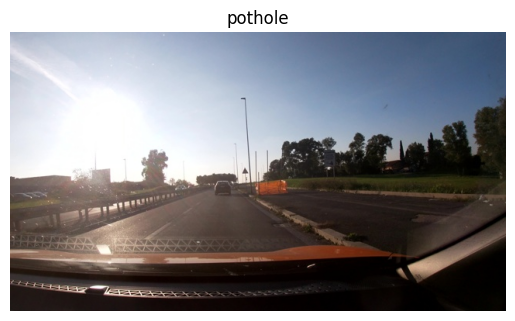

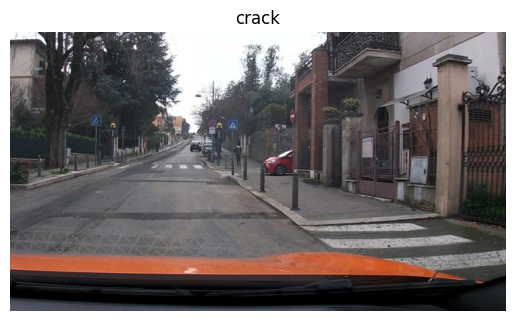

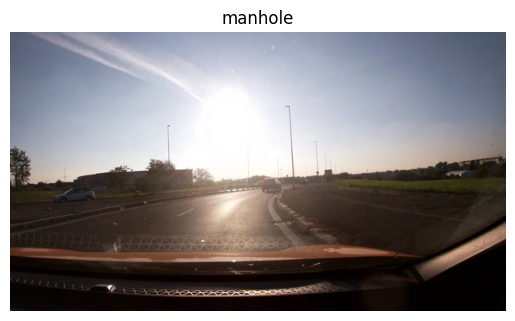

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

for class_name in classes.values():

    folder = os.path.join(output_dir, class_name)

    img_name = os.listdir(folder)[0]

    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    plt.show()

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [20]:
train_data = datagen.flow_from_directory(
    output_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 1608 images belonging to 3 classes.


In [21]:
val_data = datagen.flow_from_directory(
    output_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 401 images belonging to 3 classes.


Why Augmentation is Important

-increases dataset diversity

-reduces overfitting

-improves generalization

-helps model handle real-world variations

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Dropout
from tensorflow.keras.layers import Conv2D,MaxPooling2D

In [23]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 52s 697ms/step - accuracy: 0.4832 - loss: 1.1738 - val_accuracy: 0.4988 - val_loss: 1.0571
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 608ms/step - accuracy: 0.4981 - loss: 1.0423 - val_accuracy: 0.4988 - val_loss: 1.0651
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 594ms/step - accuracy: 0.4938 - loss: 1.0246 - val_accuracy: 0.4988 - val_loss: 1.1900
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 614ms/step - accuracy: 0.5056 - loss: 1.0039 - val_accuracy: 0.4988 - val_loss: 1.1073
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 602ms/step - accuracy: 0.4981 - loss: 0.9831 - val_accuracy: 0.4564 - val_loss: 1.3183
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 607ms/step - accuracy: 0.5087 - loss: 0.9975 - val_accuracy: 0.3791 - val_loss: 1.1584
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 600ms/step - accuracy: 0.5062 - loss: 0.9896 - val_accuracy: 0.4913 - val_loss: 1.1200
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 608ms/step - accuracy: 0.4988 - loss: 0.9814 - val_accu

In [26]:
loss, accuracy = model.evaluate(val_data)

print("Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.3716 - loss: 1.1257
Accuracy: 0.37157106399536133


In [27]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

print(classification_report(val_data.classes, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 510ms/step
              precision    recall  f1-score   support

           0       0.50      0.80      0.61       200
           1       0.25      0.15      0.19       108
           2       0.18      0.03      0.05        93

    accuracy                           0.45       401
   macro avg       0.31      0.33      0.29       401
weighted avg       0.36      0.45      0.37       401



In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [29]:
import numpy as np
import matplotlib.pyplot as plt

class_names = list(train_data.class_indices.keys())

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)

y_true = val_data.classes

wrong = np.where(y_pred != y_true)[0]

print("Number of Wrong Predictions:", len(wrong))

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 418ms/step
Number of Wrong Predictions: 214


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Number of Wrong Predictions: 235


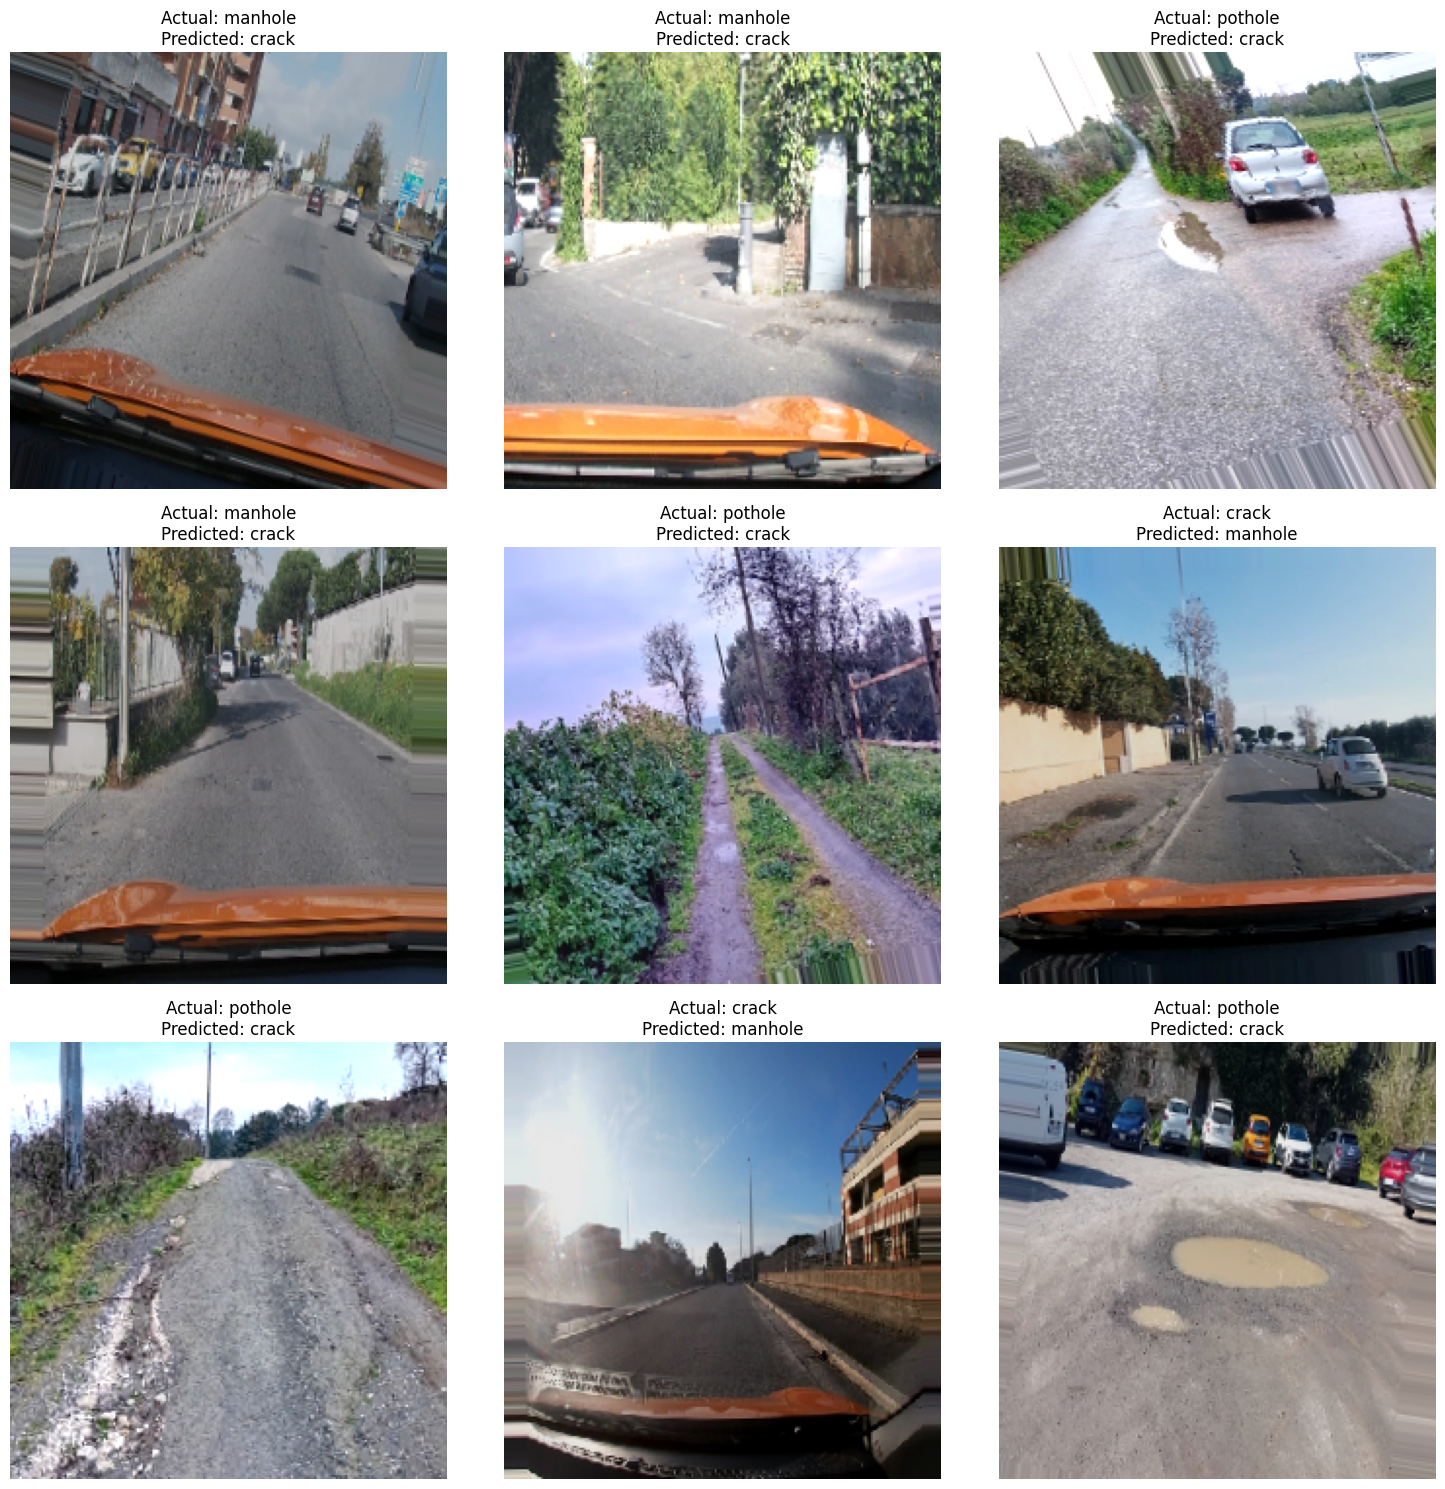

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Get all validation images and labels
x_val = []
y_val = []

for i in range(len(val_data)):
    images, labels = val_data[i]
    x_val.extend(images)
    y_val.extend(np.argmax(labels, axis=1))

x_val = np.array(x_val)
y_val = np.array(y_val)

# Predictions
predictions = model.predict(x_val)
y_pred = np.argmax(predictions, axis=1)

# Find wrong predictions
wrong = np.where(y_pred != y_val)[0]

print("Number of Wrong Predictions:", len(wrong))

class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(15,15))

for i, index in enumerate(wrong[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(x_val[index])

    actual = class_names[y_val[index]]
    predicted = class_names[y_pred[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")

    plt.axis("off")

plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Wrong Predictions: 244


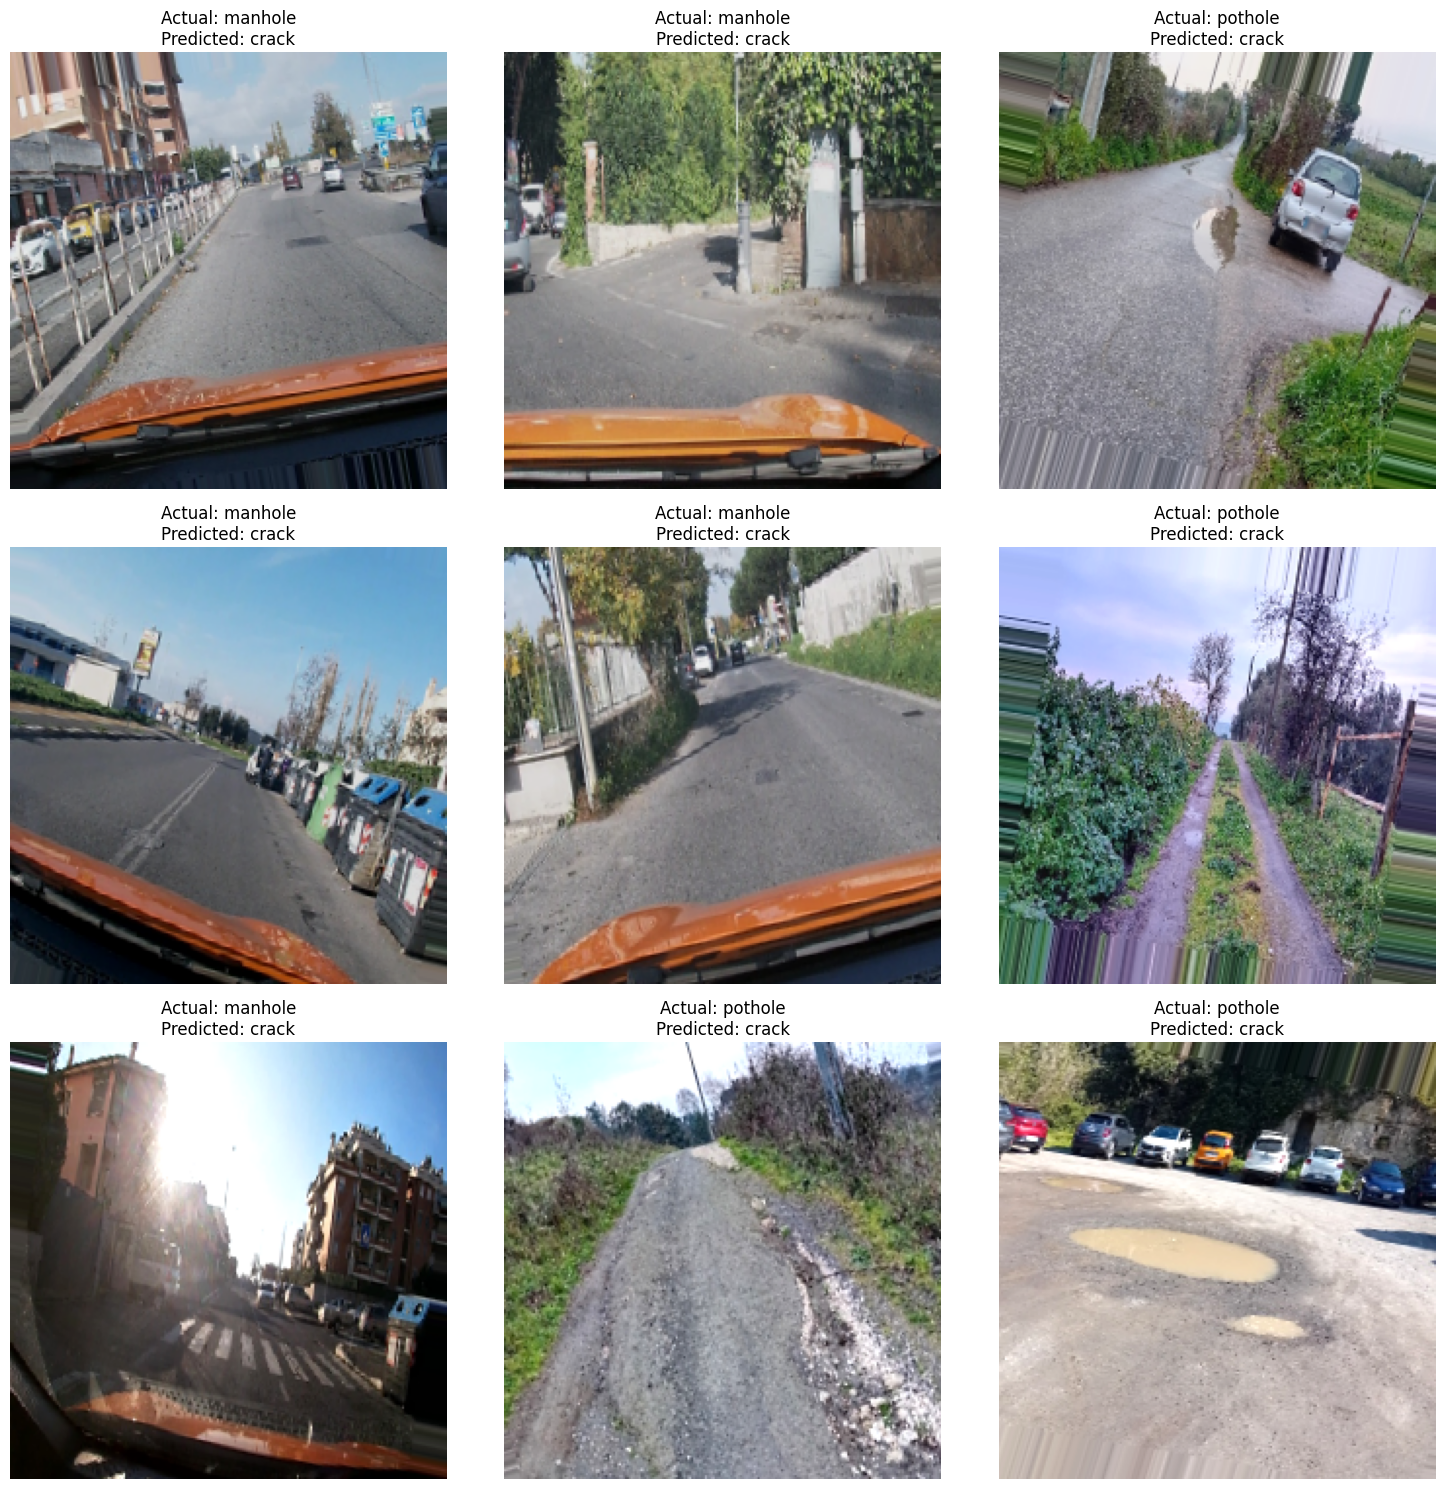

In [33]:
# Get all validation images and labels
x_val = []
y_val = []

for i in range(len(val_data)):

    images, labels = val_data[i]

    x_val.extend(images)

    y_val.extend(np.argmax(labels, axis=1))

x_val = np.array(x_val)
y_val = np.array(y_val)

# Predictions
predictions = model.predict(x_val)

y_pred = np.argmax(predictions, axis=1)

# Find wrong predictions
wrong = np.where(y_pred != y_val)[0]

print("Wrong Predictions:", len(wrong))

# Class names
class_names = list(train_data.class_indices.keys())

# Show wrongly predicted images
plt.figure(figsize=(15,15))

for i, idx in enumerate(wrong[:9]):

    plt.subplot(3,3,i+1)

    plt.imshow(x_val[idx])

    actual = class_names[y_val[idx]]
    predicted = class_names[y_pred[idx]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")

    plt.axis("off")

plt.tight_layout()
plt.show()

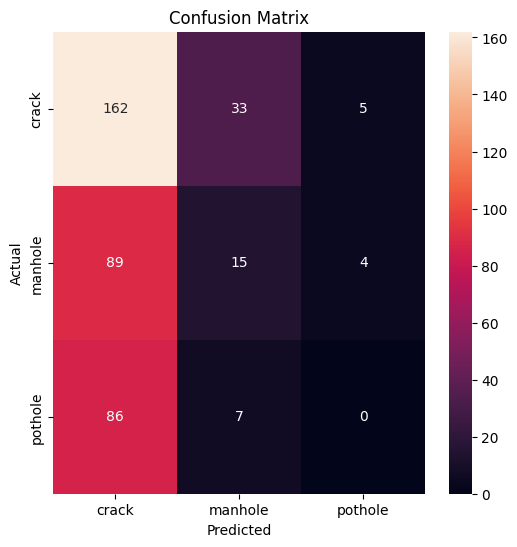

In [34]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()